<a href="https://colab.research.google.com/github/tien10022001/txldl/blob/main/lab5_lab6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Saving Untitled.png to Untitled.png


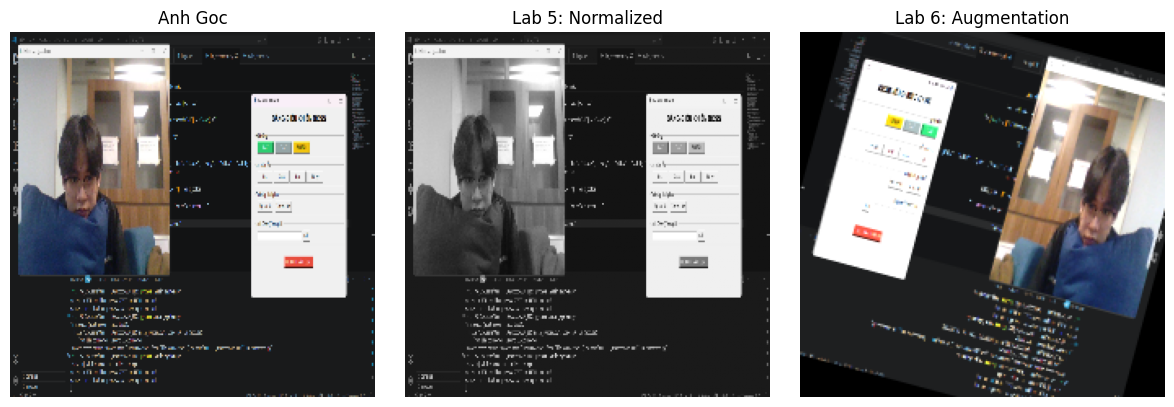

Hoan thanh Lab 5 va Lab 6.


In [2]:
# ================================
# IMPORT THƯ VIỆN
# ================================
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

# ================================
# UPLOAD ẢNH
# ================================
uploaded = files.upload()  # chọn ảnh (ví dụ: noi that 1.jpg)

# Lấy tên file vừa upload
img_path = list(uploaded.keys())[0]


# --- PHẦN 1: LAB 5 - XỬ LÝ ẢNH CƠ BẢN ---
def lab5_processing(img_path):
    # 1. Đọc ảnh
    img = cv2.imread(img_path)
    if img is None:
        return "Không tìm thấy file ảnh!"

    # 2. Resize về 224x224
    img_resized = cv2.resize(img, (224, 224))

    # 3. Chuyển sang ảnh xám
    gray = cv2.cvtColor(img_resized, cv2.COLOR_BGR2GRAY)

    # 4. Chuẩn hóa về [0, 1]
    normalized = gray.astype(np.float32) / 255.0

    return img_resized, normalized


# --- PHẦN 2: LAB 6 - DATA AUGMENTATION ---
def lab6_augmentation(img):
    # A. Xoay ảnh ngẫu nhiên (ví dụ xoay 15 độ)
    (h, w) = img.shape[:2]
    center = (w // 2, h // 2)
    M = cv2.getRotationMatrix2D(center, 15, 1.0)
    rotated = cv2.warpAffine(img, M, (w, h))

    # B. Lật ảnh ngang (Horizontal Flip)
    flipped = cv2.flip(rotated, 1)

    # C. Chỉnh độ sáng (tăng 1.2 lần)
    brightened = np.clip(flipped * 1.2, 0, 255).astype(np.uint8)

    return brightened


# --- THỰC THI VÀ HIỂN THỊ ---
try:
    # Chạy Lab 5
    original, processed = lab5_processing(img_path)

    # Chạy Lab 6 trên ảnh đã resize
    aug_img = lab6_augmentation(original)

    # Hiển thị kết quả đơn giản
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 3, 1)
    plt.title("Anh Goc")
    plt.imshow(cv2.cvtColor(original, cv2.COLOR_BGR2RGB))
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.title("Lab 5: Normalized")
    plt.imshow(processed, cmap='gray')
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.title("Lab 6: Augmentation")
    plt.imshow(cv2.cvtColor(aug_img, cv2.COLOR_BGR2RGB))
    plt.axis("off")

    plt.tight_layout()
    plt.show()

    print("Hoan thanh Lab 5 va Lab 6.")

except Exception as e:
    print(f"Loi: {e}")